Text(0.5, 1.0, 'Energy and Buckling Height vs Strain for Relaxed BiSb')

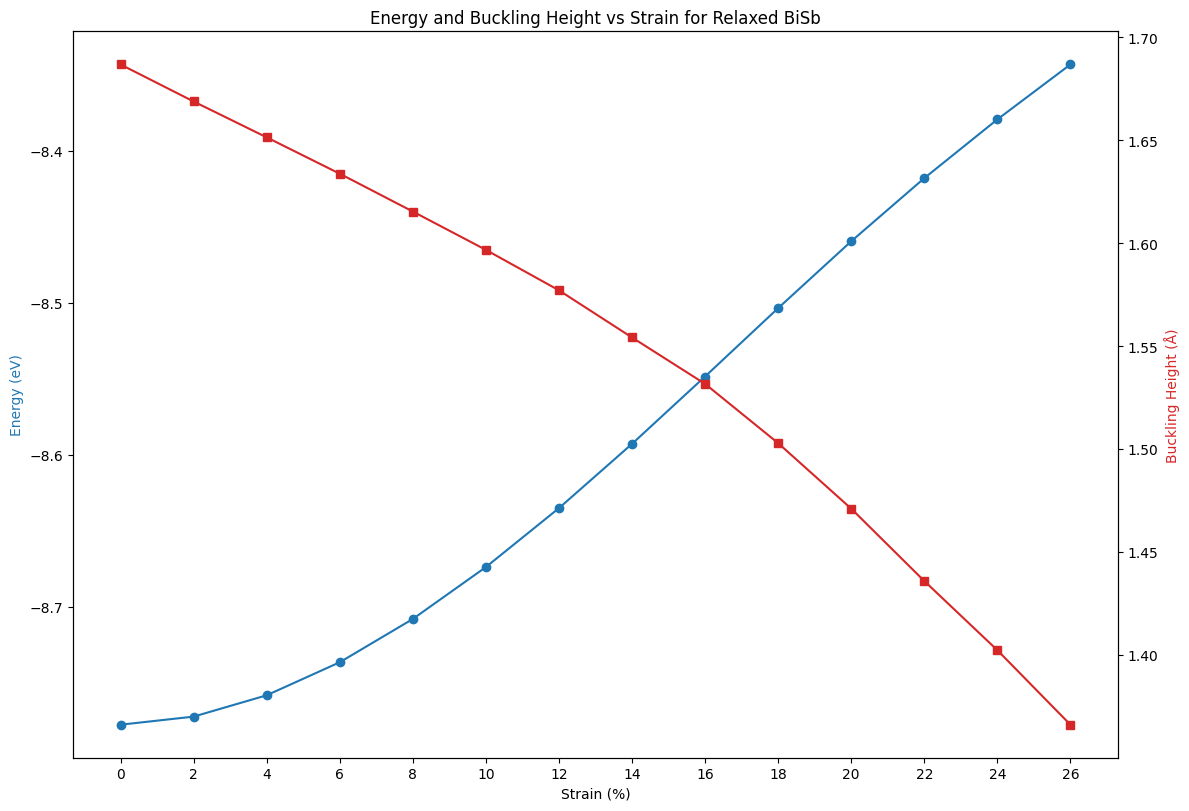

In [7]:
import numpy as np
import matplotlib.pyplot as plt

#Strain and buckling height parameters
strain = np.array([0,2,4,6,8,10,12,14,16,18,20,22,24,26])
buckling_height = np.array([1.68685,1.66888,1.65145,
                            1.63379,1.61542,1.59679,
                            1.57714,1.55423,1.53169,
                            1.50289,1.47108,1.43594,
                            1.40232,1.36611])

energies = np.array([-.87776657E+01,-.87723380E+01,
                     -.87583034E+01,-.87365641E+01,
                     -.87080878E+01,-.86739171E+01,
                     -.86351296E+01,-.85928230E+01,
                     -.85484714E+01,-.85034839E+01,
                     -.84594837E+01,-.84179326E+01,
                     -.83792574E+01,-.83430777E+01])
#Plotting energy and buckling height vs strain
fig, ax1 = plt.subplots(figsize=(12,8))
color = 'tab:blue'
ax1.set_xlabel('Strain (%)')
ax1.set_ylabel('Energy (eV)', color=color)
ax1.plot(strain, energies, marker='o', color=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Buckling Height (Å)', color=color)
ax2.plot(strain, buckling_height, marker='s', color=color)

plt.xticks(strain)
fig.tight_layout()
plt.title('Energy and Buckling Height vs Strain for Relaxed BiSb')

Number of bands below Fermi level in DFT data: 20


(-3.0, 3.0)

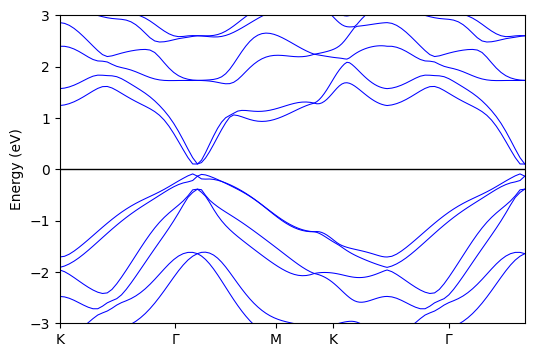

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data_dft = np.loadtxt("0-REFORMATTED_BAND.dat")

k_dft = data_dft[:, 0]
band_dft = data_dft[:, 1:]

high_symmetry_points = [0,0.780,1.456,1.846,2.626]
high_sym_labels = ['K',r'$\Gamma$','M', 'K', r'$\Gamma$',]

#number of bands below fermi level in DFT data
num_bands_below_fermi = np.sum(band_dft[0, :] < 0) 
print(f"Number of bands below Fermi level in DFT data: {num_bands_below_fermi}")

plt.figure(figsize=(6,4))

for i in range(band_dft.shape[1]):
    plt.plot(k_dft, band_dft[:, i], color='blue', linewidth=0.75, label='DFT' if i == 0 else "")
  

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.xticks(high_symmetry_points, high_sym_labels)
plt.ylabel('Energy (eV)')
#plt.title('Band Structure for $\epsilon$ = 24', fontsize=16)
plt.xlim(min(k_dft), max(k_dft))
plt.ylim(-3, 3)


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2026-01-06 15:10:45,149                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

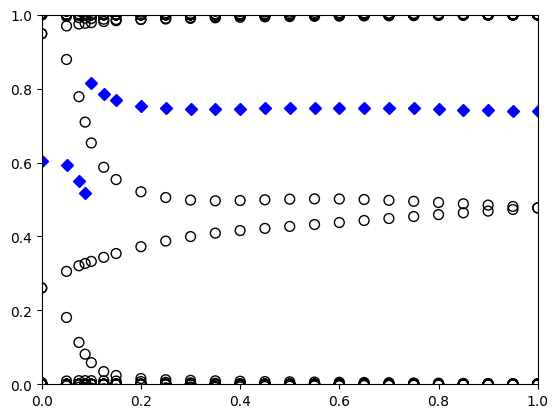

In [5]:
import z2pack, tbmodels
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='16-wannier90_hr.dat', wsvec_file='16-wannier90_wsvec.dat',occ=20)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda s, t: [s/2 , t, 0.5], num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# ==========================================
# 1. CONFIGURATION SECTION
# ==========================================

# Add your files here in the format: (File_Number, "Atom_Name")
# The code assumes filenames look like: "{number}-PBAND_{atom}_SOC.dat"
file_targets = [
    ("0", "Bi"),
    ("2", "Bi"),
    ("4", "Bi"),
    ("6", "Bi"),
    ("8", "Bi"),
    ("10", "Bi"),
    ("12", "Bi"),
    ("14", "Bi"),
    ("16", "Bi"),
    ("18", "Bi"),
    ("20", "Bi"),
    ("22", "Bi"),
    ("24", "Bi"),
    ("26", "Bi"),
    ("0", "Sb"),
    ("2", "Sb"),
    ("4", "Sb"),
    ("6", "Sb"),
    ("8", "Sb"),
    ("10", "Sb"),
    ("12", "Sb"),
    ("14", "Sb"),
    ("16", "Sb"),
    ("18", "Sb"),
    ("20", "Sb"),
    ("22", "Sb"),
    ("24", "Sb"),
    ("26", "Sb"),
]

# Shared Plot Settings
Y_LIM = (-4, 4)
XTICK_LABELS = ['K', '$\Gamma$', 'M', 'K', '$\Gamma$']
# XTICK_POSITIONS will be calculated dynamically from the data, 
# or you can hardcode them if they are identical for all files.

# ==========================================
# 2. FUNCTIONS
# ==========================================

def get_detailed_atom_data(filename):
    """Loads k-points, energy, and orbital projections from the file."""
    try:
        df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)
        k = df[0].to_numpy()
        e = df[1].to_numpy()
        # Returns: k, e, s, py, pz, px
        return k, e, df[2].to_numpy(), df[3].to_numpy(), df[4].to_numpy(), df[5].to_numpy()
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found. Skipping...")
        return None

def get_band_segments(k_pts):
    """Identifies where the band path breaks (discontinuities in k-space)."""
    band_indices = []
    start_index = 0
    for i in range(1, len(k_pts)):
        if k_pts[i] <= k_pts[i-1]:
            band_indices.append((start_index, i))
            start_index = i
    band_indices.append((start_index, len(k_pts)))
    return band_indices

# ==========================================
# 3. MAIN LOOP
# ==========================================

for file_num, atom_name in file_targets:
    # Construct filename dynamically
    filename = f"{file_num}-PBAND_{atom_name}_SOC.dat"
    print(f"\nProcessing: {filename}...")

    # Load Data
    data = get_detailed_atom_data(filename)
    if data is None: continue # Skip if file doesn't exist

    k_pts, eng, s, py, pz, px = data

    # Define Orbitals with Dynamic Labels
    # Bi/Sb (Warm/Darker tones) | (Cool/Bright tones)
    orbital_data = [
        # Data    Color       Label
        (s,  '#D62728', f'{atom_name}-s'), 
        (px, '#2CA02C', f'{atom_name}-px'), 
        (py, "#F8E800", f'{atom_name}-py'), 
        (pz, "#002FFF", f'{atom_name}-pz'), 
    ]

    # Get Band Segments
    band_indices = get_band_segments(k_pts)

    # Setup Plot
    fig, ax = plt.subplots(figsize=(6, 5))

    # SETTINGS FOR "PUNCHY" LOOK
    width_scale = 9       
    alpha_constant = 0.9   
    power_scale = 0.7      

    # Plot Colored Segments
    for start, end in band_indices:
        k_band = k_pts[start:end]
        e_band = eng[start:end]
        
        for j in range(len(k_band) - 1):
            segment_contribs = []
            
            # Calculate weights
            for w_arr, color, label in orbital_data:
                idx = start + j
                # Average weight between two points
                raw_w = (w_arr[idx] + w_arr[idx+1]) / 2
                # Normalize by max weight of that orbital type across the whole file
                norm_w = raw_w / (np.max(w_arr) + 1e-9) # Avoid divide by zero
                segment_contribs.append((norm_w, color))
            
            # Sort: Thickest lines on BOTTOM
            segment_contribs.sort(reverse=True, key=lambda x: x[0])
            
            for norm_w, color in segment_contribs:
                # Non-linear scaling
                boosted_w = np.power(norm_w, power_scale)
                lw = boosted_w * width_scale
                
                if lw > 0.2: # Optimization: Don't draw invisible lines
                    ax.plot(k_band[j:j+2], e_band[j:j+2], 
                            color=color, 
                            linewidth=lw, 
                            alpha=alpha_constant, 
                            solid_capstyle='round', 
                            zorder=1)

    # Skeleton (Black line)
    for start, end in band_indices:
        ax.plot(k_pts[start:end], eng[start:end], color='black', lw=0.8, alpha=1.0, zorder=0)

    # Formatting
    ax.set_ylim(Y_LIM)
    ax.set_xlim(min(k_pts), max(k_pts))
    ax.set_ylabel(r'$E-E_f$ (eV)', fontsize=14)
    ax.axhline(0, ls='--', lw=1, color='black')
    
    # X-Ticks (Assuming standard path points)
    # Note: If your high-symmetry points differ per file, calculate them from k_pts
    xtick_locs = [0, 0.954, 1.781, 2.258, max(k_pts)] 
    ax.set_xticks(xtick_locs)
    ax.set_xticklabels(XTICK_LABELS, fontsize=12)

    # Legend
    legend_elements = [Line2D([0], [0], color=c, lw=4, label=l) for _, c, l in orbital_data]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=1, shadow=True)

    plt.tight_layout()
    
    # Save file
    output_png = f"Band_Structure_{atom_name}_{file_num}.png"
    plt.savefig(output_png, dpi=300)
    print(f"Saved: {output_png}")
    
    # Clear memory
    plt.close(fig) 

print("\nAll plots generated!")


Processing: 0-PBAND_Bi_SOC.dat...


C:\Users\furka\AppData\Local\Temp\ipykernel_12092\3831739212.py:57: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Saved: Band_Structure_Bi_0.png

Processing: 2-PBAND_Bi_SOC.dat...


C:\Users\furka\AppData\Local\Temp\ipykernel_12092\3831739212.py:57: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Saved: Band_Structure_Bi_2.png

Processing: 4-PBAND_Bi_SOC.dat...


...

Saved: Band_Structure_Sb_22.png

Processing: 24-PBAND_Sb_SOC.dat...


C:\Users\furka\AppData\Local\Temp\ipykernel_12092\3831739212.py:57: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Saved: Band_Structure_Sb_24.png

Processing: 26-PBAND_Sb_SOC.dat...


C:\Users\furka\AppData\Local\Temp\ipykernel_12092\3831739212.py:57: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Saved: Band_Structure_Sb_26.png

All plots generated!
